In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

100.0%
100.0%
100.0%
100.0%


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)  # logits

In [ ]:
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(train_loader), 100. * correct / total

In [ ]:
def evaluate(model, device, test_loader, criterion):
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            test_loss += criterion(outputs, labels).item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
    return test_loss / len(test_loader), 100. * correct / len(test_loader.dataset)

In [ ]:
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

In [ ]:
for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

Epoch 1: Train Acc=91.47%, Test Acc=97.91%
Epoch 2: Train Acc=97.02%, Test Acc=98.76%
Epoch 3: Train Acc=97.98%, Test Acc=98.72%
Epoch 4: Train Acc=98.16%, Test Acc=98.86%
Epoch 5: Train Acc=98.55%, Test Acc=99.04%
Epoch 6: Train Acc=98.73%, Test Acc=99.10%
Epoch 7: Train Acc=98.84%, Test Acc=99.24%
Epoch 8: Train Acc=99.00%, Test Acc=99.34%
Epoch 9: Train Acc=99.12%, Test Acc=99.34%
Epoch 10: Train Acc=99.12%, Test Acc=99.32%


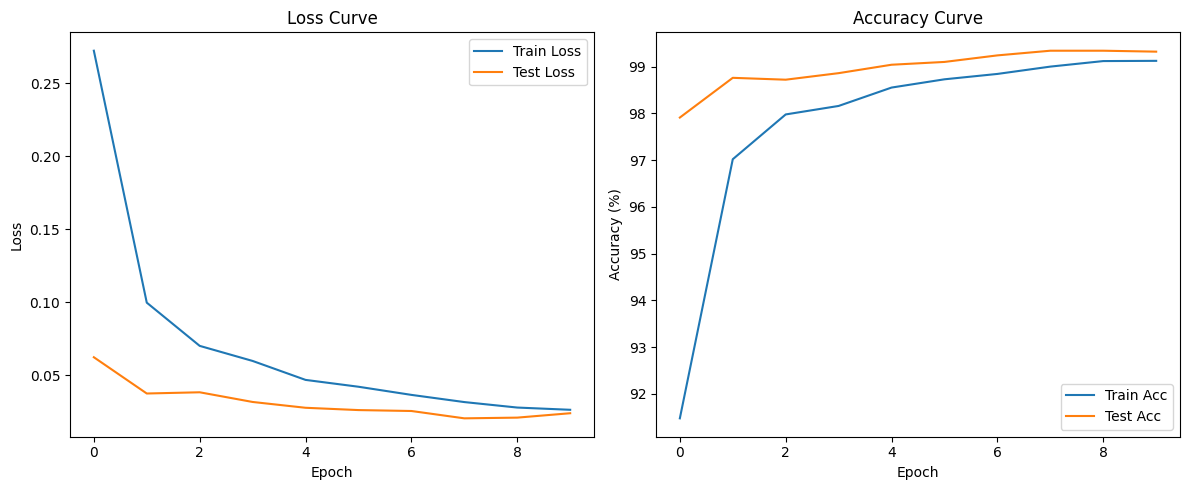

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

From this point on we will vary some settings and see the results

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

We tweak the Optimizer with sgd.

Epoch 1: Train Acc=91.38%, Test Acc=98.21%
Epoch 2: Train Acc=97.04%, Test Acc=98.82%
Epoch 3: Train Acc=97.69%, Test Acc=98.91%
Epoch 4: Train Acc=98.16%, Test Acc=98.97%
Epoch 5: Train Acc=98.41%, Test Acc=99.06%
Epoch 6: Train Acc=98.58%, Test Acc=99.05%
Epoch 7: Train Acc=98.75%, Test Acc=99.17%
Epoch 8: Train Acc=98.97%, Test Acc=99.23%
Epoch 9: Train Acc=98.90%, Test Acc=99.09%
Epoch 10: Train Acc=99.08%, Test Acc=99.23%


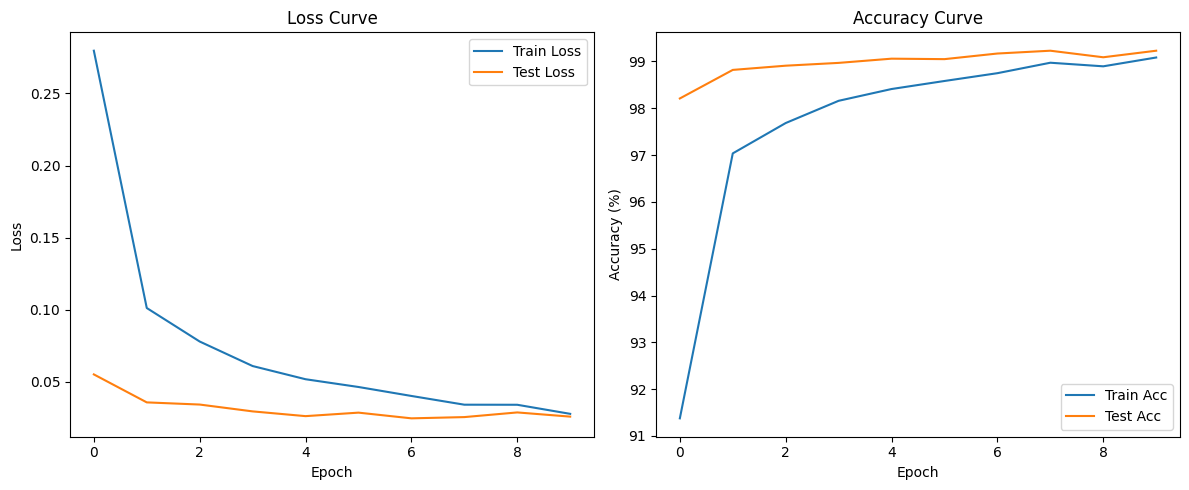

In [ ]:
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

#Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

It made us reach higher test accuracy faster but our original settings got better at the end.

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.0001)

Setting back to start conditions. and lowering learning rate

Epoch 1: Train Acc=91.20%, Test Acc=97.72%
Epoch 2: Train Acc=96.96%, Test Acc=98.67%
Epoch 3: Train Acc=97.71%, Test Acc=98.88%
Epoch 4: Train Acc=98.18%, Test Acc=99.09%
Epoch 5: Train Acc=98.40%, Test Acc=99.05%
Epoch 6: Train Acc=98.51%, Test Acc=99.06%
Epoch 7: Train Acc=98.78%, Test Acc=99.16%
Epoch 8: Train Acc=98.91%, Test Acc=99.31%
Epoch 9: Train Acc=98.96%, Test Acc=99.28%
Epoch 10: Train Acc=99.08%, Test Acc=99.26%


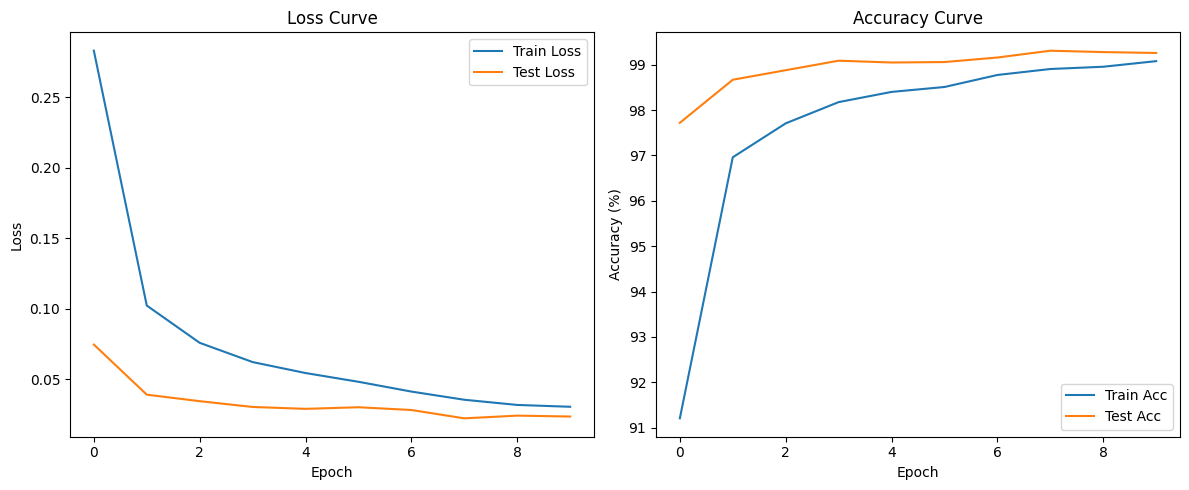

In [ ]:
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

#Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

Learning rate really hindered its speed it couldnt reach the accuracies baseline reached.

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

Epoch 1: Train Acc=91.06%, Test Acc=98.05%
Epoch 2: Train Acc=96.93%, Test Acc=98.62%
Epoch 3: Train Acc=97.67%, Test Acc=98.88%
Epoch 4: Train Acc=98.18%, Test Acc=98.90%
Epoch 5: Train Acc=98.34%, Test Acc=98.83%
Epoch 6: Train Acc=98.58%, Test Acc=99.07%
Epoch 7: Train Acc=98.74%, Test Acc=99.20%
Epoch 8: Train Acc=98.88%, Test Acc=99.26%
Epoch 9: Train Acc=99.00%, Test Acc=99.25%
Epoch 10: Train Acc=99.12%, Test Acc=99.14%


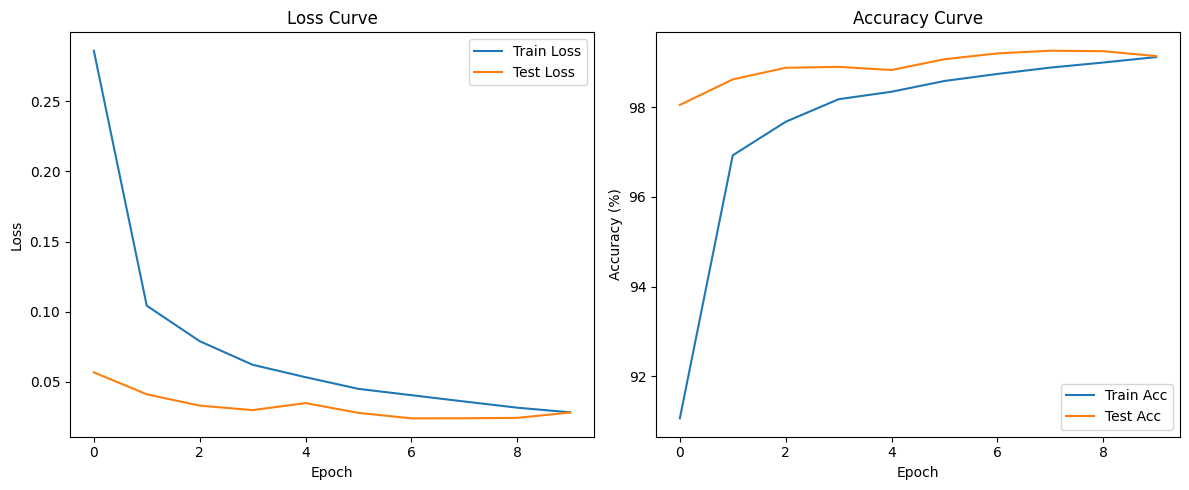

In [ ]:
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

#Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

On the other hand taking learning rate too high caused it to be even less accurate then the last one.

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

Resetting

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

Epoch 1: Train Acc=92.69%, Test Acc=98.32%
Epoch 2: Train Acc=97.20%, Test Acc=98.68%
Epoch 3: Train Acc=97.93%, Test Acc=98.89%
Epoch 4: Train Acc=98.29%, Test Acc=98.99%
Epoch 5: Train Acc=98.53%, Test Acc=98.88%
Epoch 6: Train Acc=98.77%, Test Acc=99.12%
Epoch 7: Train Acc=98.86%, Test Acc=99.04%
Epoch 8: Train Acc=99.01%, Test Acc=99.31%
Epoch 9: Train Acc=99.06%, Test Acc=99.18%
Epoch 10: Train Acc=99.17%, Test Acc=99.18%


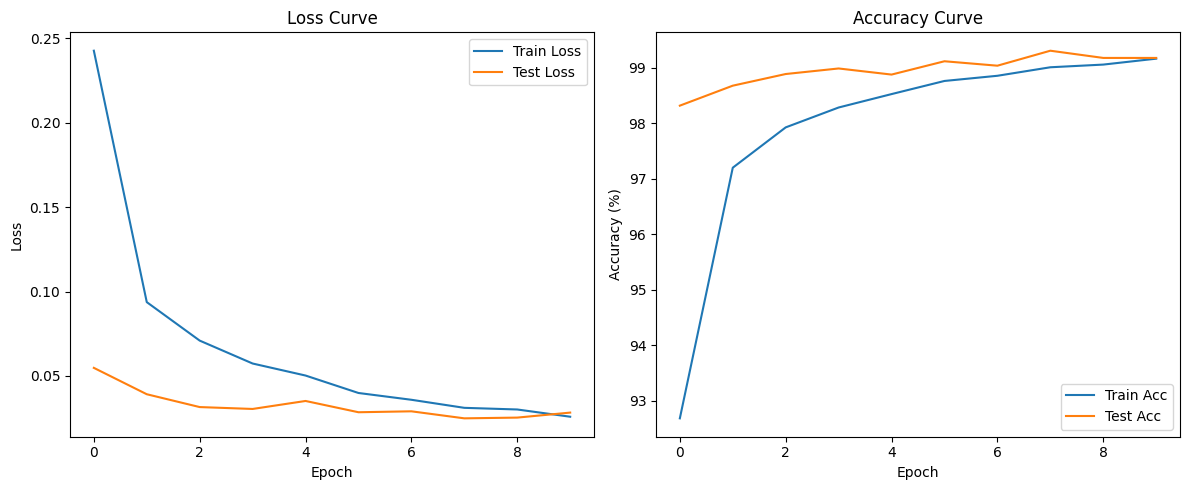

In [ ]:
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

#Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

With this batch size we got really big waves and slower learning rate.

In [ ]:
test_loader = DataLoader(test_dataset, batch_size=1000)

Epoch 1: Train Acc=92.36%, Test Acc=98.17%
Epoch 2: Train Acc=97.07%, Test Acc=98.81%
Epoch 3: Train Acc=97.86%, Test Acc=98.91%
Epoch 4: Train Acc=98.28%, Test Acc=99.14%
Epoch 5: Train Acc=98.45%, Test Acc=99.24%
Epoch 6: Train Acc=98.68%, Test Acc=99.06%
Epoch 7: Train Acc=98.88%, Test Acc=99.12%
Epoch 8: Train Acc=98.98%, Test Acc=99.28%
Epoch 9: Train Acc=99.07%, Test Acc=99.04%
Epoch 10: Train Acc=99.17%, Test Acc=99.33%


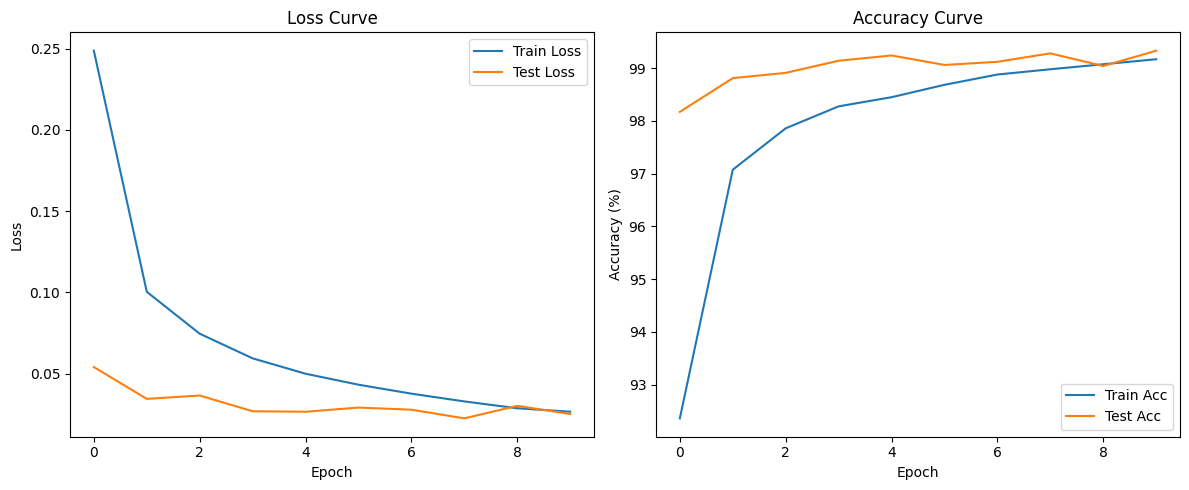

In [ ]:
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

#Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

And adding the test data batch size to 1000 we got even more rippling in training test.

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

Resetting.

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)  # logits

Making models dropout lower.

Epoch 1: Train Acc=93.60%, Test Acc=98.29%
Epoch 2: Train Acc=98.18%, Test Acc=98.72%
Epoch 3: Train Acc=98.65%, Test Acc=98.93%
Epoch 4: Train Acc=98.95%, Test Acc=98.65%
Epoch 5: Train Acc=99.12%, Test Acc=99.06%
Epoch 6: Train Acc=99.22%, Test Acc=99.05%
Epoch 7: Train Acc=99.39%, Test Acc=99.11%
Epoch 8: Train Acc=99.43%, Test Acc=99.05%
Epoch 9: Train Acc=99.46%, Test Acc=99.14%
Epoch 10: Train Acc=99.59%, Test Acc=99.19%


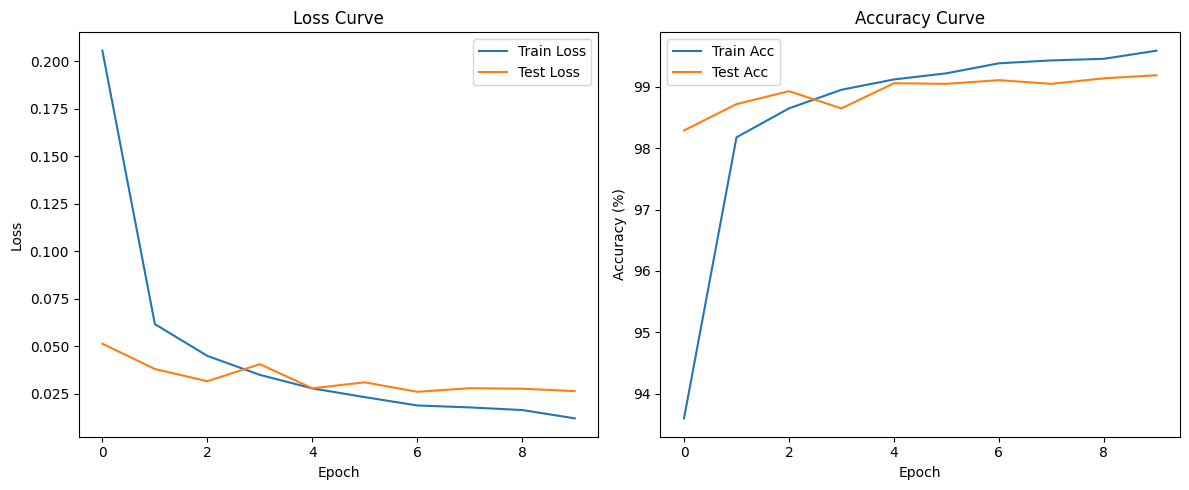

In [ ]:
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

#Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

With lowering dropout rate we slowed it a lot but after epoch 4 or 5 it isnt bothered by it.

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.8)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)  # logits

Making dropout longer.

Epoch 1: Train Acc=76.78%, Test Acc=97.43%
Epoch 2: Train Acc=87.40%, Test Acc=98.27%
Epoch 3: Train Acc=89.97%, Test Acc=98.53%
Epoch 4: Train Acc=91.19%, Test Acc=98.77%
Epoch 5: Train Acc=92.24%, Test Acc=98.95%
Epoch 6: Train Acc=93.53%, Test Acc=99.06%
Epoch 7: Train Acc=94.02%, Test Acc=99.17%
Epoch 8: Train Acc=94.52%, Test Acc=99.17%
Epoch 9: Train Acc=94.94%, Test Acc=99.01%
Epoch 10: Train Acc=95.32%, Test Acc=99.29%


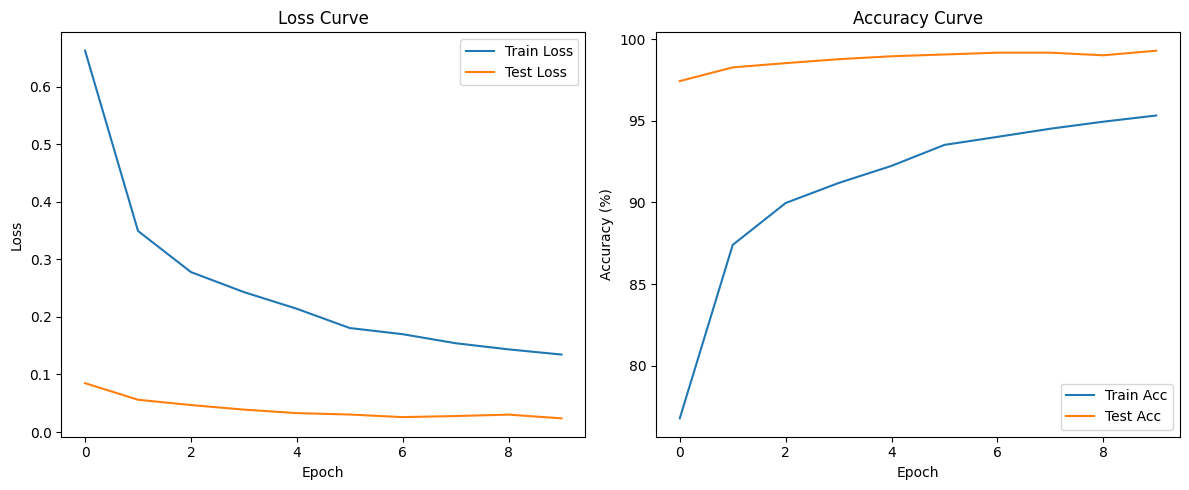

In [ ]:
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

#Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

Making dropout this big made it so it leanred training too well and it took test accuracy very long time to catch up to our baseline accuracy levels. 

In [ ]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        torch.nn.init.kaiming_uniform_(m.weight)

Epoch 1: Train Acc=76.61%, Test Acc=97.44%
Epoch 2: Train Acc=87.42%, Test Acc=98.27%
Epoch 3: Train Acc=89.69%, Test Acc=98.49%
Epoch 4: Train Acc=91.03%, Test Acc=98.69%
Epoch 5: Train Acc=91.78%, Test Acc=98.85%
Epoch 6: Train Acc=92.16%, Test Acc=98.94%
Epoch 7: Train Acc=92.76%, Test Acc=98.99%
Epoch 8: Train Acc=93.07%, Test Acc=99.17%
Epoch 9: Train Acc=93.43%, Test Acc=99.14%
Epoch 10: Train Acc=94.13%, Test Acc=99.14%


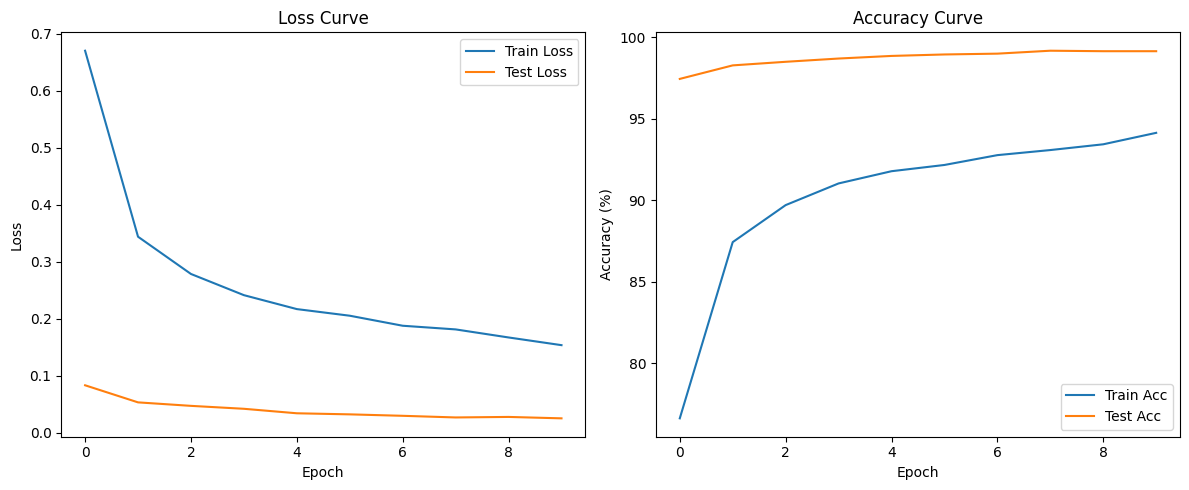

In [ ]:
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(10):
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, device, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")

#Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies, label="Test Acc")
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

With weights initialized we got a slower start but at the end it looked like it can still grow very interesting.